In [342]:
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Input, Dropout
from keras.layers import Dense
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Model
import seaborn as sns
import scipy

In [261]:
data = pd.read_csv('./data/GE.csv')
data = data.drop('Open', axis = 1)

In [262]:
data.head()

,Date,High,Low,Close,Adj Close,Volume
0,1970-01-23,5.959535,5.839343,5.849359,1.207645,476736
1,1970-01-26,5.859375,5.829327,5.849359,1.207645,283296
2,1970-01-27,5.959535,5.849359,5.939503,1.226255,247104
3,1970-01-28,6.009615,5.939503,5.939503,1.226255,545376
4,1970-01-29,5.989583,5.879407,5.879407,1.213848,466752


([<matplotlib.axis.XTick at 0x17746d4c5b0>,
 [Text(0, 0, '1970-01-23'),
  Text(1600, 0, '1976-05-24'),
  Text(3200, 0, '1982-09-23'),
  Text(4800, 0, '1989-01-20'),
  Text(6400, 0, '1995-05-19'),
  Text(8000, 0, '2001-09-26'),
  Text(9600, 0, '2008-02-05'),
  Text(11200, 0, '2014-06-13'),
  Text(12800, 0, '2020-10-20')])

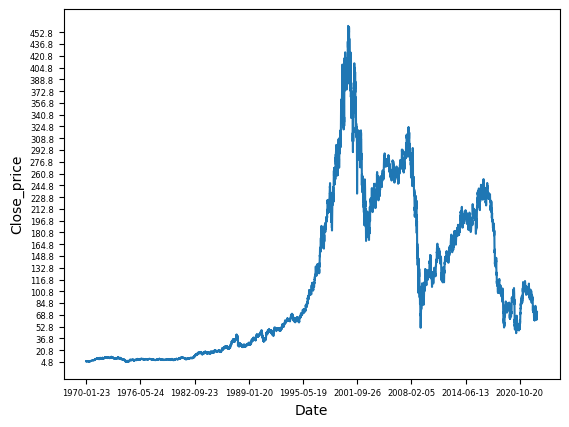

In [263]:
plt.plot(data['Date'], data['Close'])
plt.xlabel('Date')
plt.ylabel('Close_price')
plt.yticks(np.arange(data['Close'].min(), data['Close'].max(), 16),size = 6)
plt.xticks([ i for i in range(0,data.count()[0],1600) ], size = 6)

In [283]:
train, test = data.iloc[:int(len(data)*0.6),:], data.iloc[int(len(data)*0.6):,:]

In [284]:
scaler = MinMaxScaler()
scaler = scaler.fit(train[['Close']])

In [285]:
train['Close'] = scaler.transform(train[['Close']])
test['Close'] = scaler.transform(test[['Close']])

C:\Users\1\AppData\Local\Temp\ipykernel_16984\2411660821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Close'] = scaler.transform(train[['Close']])
C:\Users\1\AppData\Local\Temp\ipykernel_16984\2411660821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Close'] = scaler.transform(test[['Close']])


In [286]:
seq_size = 30

In [287]:
def to_sequences(x, y, seq_size=1):
    x_values = []
    y_values = []

    for i in range(len(x)-seq_size):
        #print(i)
        x_values.append(x.iloc[i:(i+seq_size)].values)
        y_values.append(y.iloc[i+seq_size])

    return np.array(x_values), np.array(y_values)

In [288]:
trainX, trainY = to_sequences(train[['Close']], train['Close'], seq_size)
testX, testY = to_sequences(test[['Close']], test['Close'], seq_size)

In [289]:
np.random.seed(10)

In [290]:
model = Sequential()
model.add(LSTM(128, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(rate=0.2))

model.add(RepeatVector(trainX.shape[1]))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(rate=0.2))
model.add(TimeDistributed(Dense(trainX.shape[2])))
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_32"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_58 (LSTM)              (None, 128)               66560     
                                                                 
 dropout_33 (Dropout)        (None, 128)               0         
                                                                 
 repeat_vector_25 (RepeatVec  (None, 30, 128)          0         
 tor)                                                            
                                                                 
 lstm_59 (LSTM)              (None, 30, 128)           131584    
                                                                 
 dropout_34 (Dropout)        (None, 30, 128)           0         
                                                                 
 time_distributed_20 (TimeDi  (None, 30, 1)            129       
 stributed)                                          

In [291]:

history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/10
224/224 [==============================] - 12s 41ms/step - loss: 0.0086 - val_loss: 0.4259
Epoch 2/10
224/224 [==============================] - 9s 39ms/step - loss: 0.0086 - val_loss: 0.4335
Epoch 3/10
224/224 [==============================] - 14s 62ms/step - loss: 0.0085 - val_loss: 0.4219
Epoch 4/10
224/224 [==============================] - 14s 61ms/step - loss: 0.0085 - val_loss: 0.4109
Epoch 5/10
224/224 [==============================] - 12s 55ms/step - loss: 0.0085 - val_loss: 0.4143
Epoch 6/10
224/224 [==============================] - 11s 50ms/step - loss: 0.0085 - val_loss: 0.4106
Epoch 7/10
224/224 [==============================] - 11s 48ms/step - loss: 0.0085 - val_loss: 0.4150
Epoch 8/10
224/224 [==============================] - 12s 53ms/step - loss: 0.0085 - val_loss: 0.4212
Epoch 9/10
224/224 [==============================] - 11s 47ms/step - loss: 0.0085 - val_loss: 0.4038
Epoch 10/10
224/224 [==============================] - 10s 45ms/step - loss: 0.0085

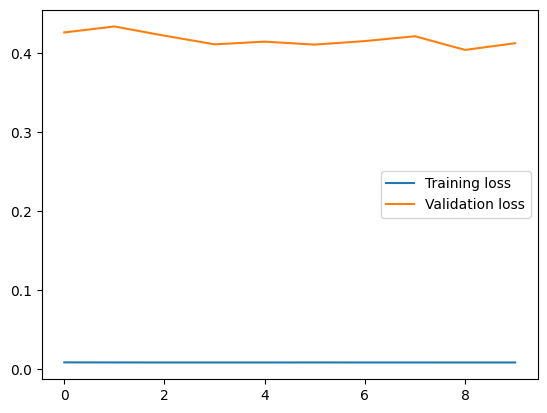

In [292]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [293]:
model.evaluate(testX, testY)

166/166 [==============================] - 2s 14ms/step - loss: 0.1182


0.11822686344385147

249/249 [==============================] - 4s 13ms/step


array([[0.06102384],
       [0.06101859],
       [0.06101444],
       ...,
       [0.63983905],
       [0.63776624],
       [0.63439697]])

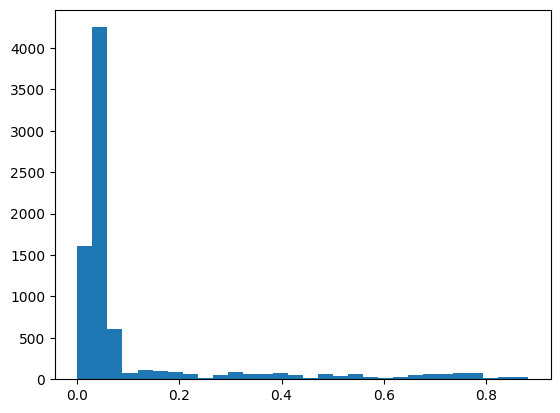

In [294]:
pred_train = model.predict(trainX)
trainMAE = np.mean(np.abs(pred_train - trainX), axis=1)
# var_train = np.var(pred_train - trainX, ddof=1)
plt.hist(trainMAE, bins=30)
trainMAE

(array([  19.,   26.,   61.,   46.,   56.,   48.,   65.,   29.,   27.,
          80.,  194.,  239.,  205.,  303.,  282.,  769.,  222., 3266.,
         417.,  117.,   59.,  110.,  104.,  135.,   51.,  180.,  184.,
         179.,  197.,  283.]),
 array([-6.82592909, -6.60257716, -6.37922523, -6.1558733 , -5.93252137,
        -5.70916944, -5.48581752, -5.26246559, -5.03911366, -4.81576173,
        -4.5924098 , -4.36905787, -4.14570594, -3.92235402, -3.69900209,
        -3.47565016, -3.25229823, -3.0289463 , -2.80559437, -2.58224244,
        -2.35889051, -2.13553859, -1.91218666, -1.68883473, -1.4654828 ,
        -1.24213087, -1.01877894, -0.79542701, -0.57207509, -0.34872316,
        -0.12537123]),
 <BarContainer object of 30 artists>)

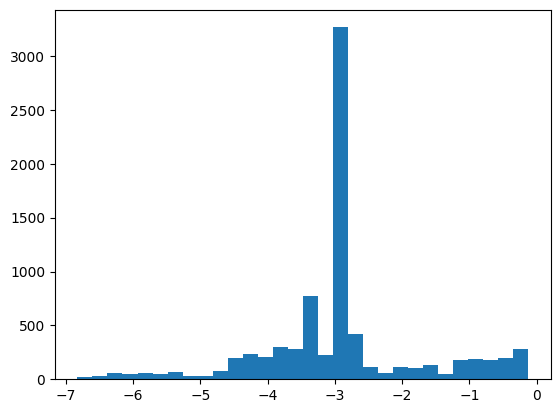

In [315]:
plt.hist(np.log(trainMAE), bins=30)

166/166 [==============================] - 2s 13ms/step


array([[[0.08998422],
        [0.08009538],
        [0.0825813 ],
        ...,
        [0.08227687],
        [0.0822772 ],
        [0.08227748]],

       [[0.0900913 ],
        [0.08017717],
        [0.08266932],
        ...,
        [0.08236405],
        [0.0823644 ],
        [0.08236466]],

       [[0.09004387],
        [0.08013952],
        [0.08262844],
        ...,
        [0.0823237 ],
        [0.08232404],
        [0.08232431]],

       ...,

       [[0.0714881 ],
        [0.0659434 ],
        [0.06732746],
        ...,
        [0.0671446 ],
        [0.06714467],
        [0.06714474]],

       [[0.07154835],
        [0.06598942],
        [0.06737705],
        ...,
        [0.06719366],
        [0.06719373],
        [0.06719379]],

       [[0.07156158],
        [0.06599917],
        [0.06738748],
        ...,
        [0.06720397],
        [0.06720404],
        [0.06720411]]], dtype=float32)

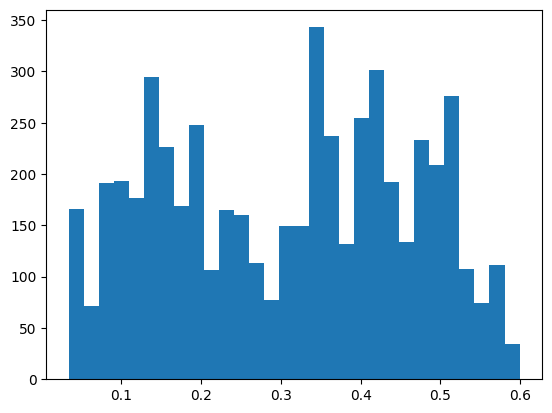

In [295]:
pred_test = model.predict(testX)
testMAE = np.mean(np.abs(pred_test - testX), axis=1)
plt.hist(testMAE, bins=30)
pred_test

(array([ 50.,  36.,  34.,  35.,  16.,  14.,  23.,  35.,  91.,  82., 124.,
         70.,  83., 145., 149., 288.,  60., 246., 183., 122., 222., 172.,
        126., 272., 542., 372., 528., 461., 497., 215.]),
 array([-3.37993053, -3.28434153, -3.18875252, -3.09316352, -2.99757452,
        -2.90198551, -2.80639651, -2.7108075 , -2.6152185 , -2.51962949,
        -2.42404049, -2.32845149, -2.23286248, -2.13727348, -2.04168447,
        -1.94609547, -1.85050646, -1.75491746, -1.65932846, -1.56373945,
        -1.46815045, -1.37256144, -1.27697244, -1.18138344, -1.08579443,
        -0.99020543, -0.89461642, -0.79902742, -0.70343841, -0.60784941,
        -0.51226041]),
 <BarContainer object of 30 artists>)

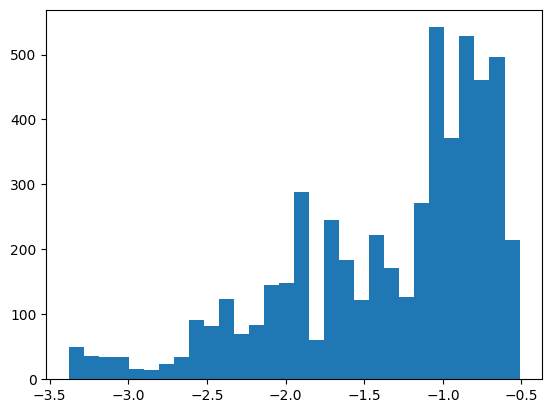

In [317]:
plt.hist(np.log(testMAE), bins=30)

In [359]:
anomaly_df = pd.DataFrame(test[seq_size:])
anomaly_df['testMAE'] = testMAE

l = []
for i in range(0,len(trainMAE)) : l.append(trainMAE[i][0])
stat = scipy.stats.describe(l)
print(stat.variance, stat.mean+ (stat.variance)**(0.5)*3)

0.03402461392649124 0.6698543502572499


In [350]:

anomaly_df['max_trainMAE'] = trainMAE.max()
anomaly_df['anomaly'] = anomaly_df['testMAE'] > stat.mean + ((stat.variance)**0.5)*3
anomaly_df['Close'] = test[seq_size:]['Close']

In [351]:
anomaly_df

,Date,High,Low,Close,Adj Close,Volume,testMAE,max_trainMAE,anomaly
8013,2001-10-15,300.615387,292.769226,0.643942,168.094635,1673555,0.540175,0.882169,False
8014,2001-10-16,301.923065,293.076935,0.637374,166.407669,2157636,0.538230,0.882169,False
8015,2001-10-17,298.153839,284.769226,0.615141,160.697876,2819635,0.536721,0.882169,False
8016,2001-10-18,288.461548,283.461548,0.616825,161.130417,1969734,0.535103,0.882169,False
8017,2001-10-19,287.692322,281.076935,0.616825,161.130417,2128451,0.533615,0.882169,False
...,...,...,...,...,...,...,...,...,...
13301,2022-10-17,70.190002,68.430000,0.139700,68.629997,5141100,0.069971,0.882169,False
13302,2022-10-18,71.139999,69.930000,0.144232,70.699997,6109700,0.069636,0.882169,False
13303,2022-10-19,70.980003,69.339996,0.143860,70.529999,5238500,0.069434,0.882169,False
13304,2022-10-20,71.610001,69.830002,0.142634,69.970001,5987100,0.069162,0.882169,False


In [299]:
anomalies = anomaly_df.loc[anomaly_df['anomaly'] == True]

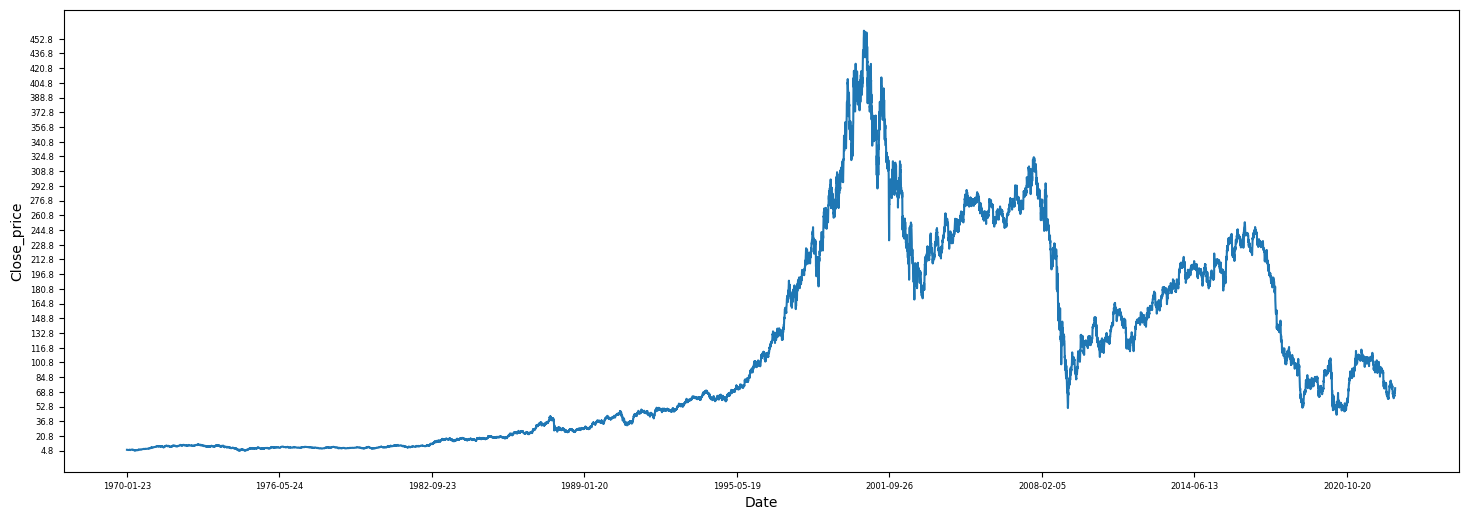

In [311]:
plt.figure(figsize= (18,6))
plt.plot(data['Date'], data['Close'])
plt.xlabel('Date')
plt.ylabel('Close_price')
plt.yticks(np.arange(data['Close'].min(), data['Close'].max(), 16),size = 6)
plt.xticks([ i for i in range(0,data.count()[0],1600) ], size = 6)


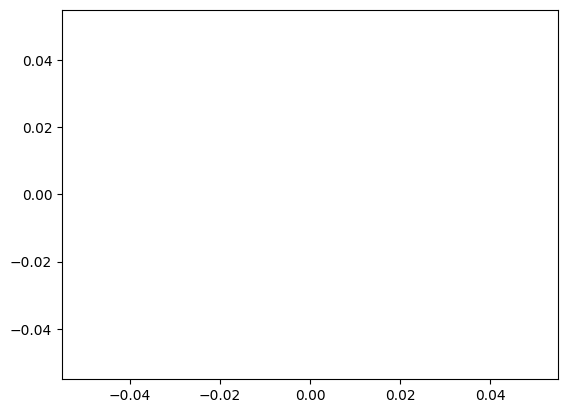

In [352]:
plt.scatter(anomaly_df['Date'][anomaly_df['anomaly'] == True], anomaly_df['Close'][anomaly_df['anomaly'] == True])

In [353]:
anomaly_df['Close'][anomaly_df['anomaly'] == True]

Series([], Name: Close, dtype: float64)

In [354]:
anomaly_df['anomaly'] = anomaly_df['testMAE'] > stat.mean + ((stat.variance)**0.5)*3
anomaly_df['3sigma'] = stat.mean + ((stat.variance)**0.5)*3

In [355]:
anomaly_df

,Date,High,Low,Close,Adj Close,Volume,testMAE,max_trainMAE,anomaly,3sigma
8013,2001-10-15,300.615387,292.769226,0.643942,168.094635,1673555,0.540175,0.882169,False,0.669854
8014,2001-10-16,301.923065,293.076935,0.637374,166.407669,2157636,0.538230,0.882169,False,0.669854
8015,2001-10-17,298.153839,284.769226,0.615141,160.697876,2819635,0.536721,0.882169,False,0.669854
8016,2001-10-18,288.461548,283.461548,0.616825,161.130417,1969734,0.535103,0.882169,False,0.669854
8017,2001-10-19,287.692322,281.076935,0.616825,161.130417,2128451,0.533615,0.882169,False,0.669854
...,...,...,...,...,...,...,...,...,...,...
13301,2022-10-17,70.190002,68.430000,0.139700,68.629997,5141100,0.069971,0.882169,False,0.669854
13302,2022-10-18,71.139999,69.930000,0.144232,70.699997,6109700,0.069636,0.882169,False,0.669854
13303,2022-10-19,70.980003,69.339996,0.143860,70.529999,5238500,0.069434,0.882169,False,0.669854
13304,2022-10-20,71.610001,69.830002,0.142634,69.970001,5987100,0.069162,0.882169,False,0.669854
